In [3]:
# --- CELL 1: SETUP ---
import os
from typing import TypedDict, List
from langgraph.graph import StateGraph, START, END
from IPython.display import Image, display


# Set your API Key (Replace with your own or use an .env file)
# os.environ["OPENAI_API_KEY"] = "your-key-here"
os.environ["GOOGLE_API_KEY"] = "your-key-here"

print("✅ Setup Complete")

✅ Setup Complete


In [4]:
# --- CELL 2: THE SHARED CLIPBOARD (STATE) ---
class SentinelState(TypedDict):
    query: str
    active_expert: str    # Current agent in control
    shared_notes: List[str]
    final_answer: str

In [5]:
# --- CELL 3: THE EXPERTS (NODES) ---

def technical_analyst_node(state: SentinelState):
    print("📉 Tech Analyst: Examining price charts and RSI...")
    notes = state.get("shared_notes", [])
    notes.append("Technical: RSI is oversold, suggesting a potential bounce.")

    # Logic: If we haven't checked news yet, hand off to News Expert
    return {"shared_notes": notes, "active_expert": "news_expert"}

def news_expert_node(state: SentinelState):
    print("📰 News Expert: Checking latest headlines...")
    notes = state.get("shared_notes", [])
    notes.append("News: Positive earnings report released 10 minutes ago.")

    # Logic: After news, we go to the Aggregator
    return {"shared_notes": notes, "active_expert": "aggregator"}

def aggregator_node(state: SentinelState):
    print("🤝 Aggregator: Summarizing expert findings...")
    summary = " | ".join(state["shared_notes"])
    return {"final_answer": f"SWARM VERDICT: {summary}"}

In [6]:
# --- CELL 4: THE HAND-OFF LOGIC ---
def swarm_router(state: SentinelState):
    """Determines which expert takes the ball next."""
    return state["active_expert"]

In [7]:
# --- CELL 5: THE FLOOR PLAN (GRAPH) ---
builder = StateGraph(SentinelState)

builder.add_node("tech_analyst", technical_analyst_node)
builder.add_node("news_expert", news_expert_node)
builder.add_node("aggregator", aggregator_node)

# Initial entry point
builder.add_edge(START, "tech_analyst")

# The "Hand-off" Edges
builder.add_conditional_edges(
    "tech_analyst",
    swarm_router,
    {"news_expert": "news_expert", "aggregator": "aggregator"}
)

builder.add_conditional_edges(
    "news_expert",
    swarm_router,
    {"tech_analyst": "tech_analyst", "aggregator": "aggregator"}
)

builder.add_edge("aggregator", END)

sentinel_swarm = builder.compile()

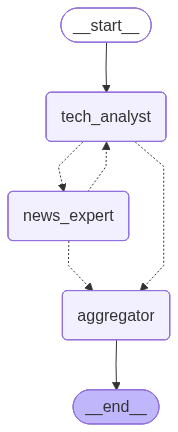

In [8]:
# --- CELL 6: VISUALIZATION ---
try:
    png_bytes = sentinel_swarm.get_graph().draw_mermaid_png()
    with open("sentinel_swarm.png", "wb") as f:
        f.write(png_bytes)
    display(Image(data=png_bytes))
except Exception as e:
    print(f"Visualization skip: {e}")

In [9]:
# --- CELL 7: RUNNING THE SWARM ---
print("\n--- STARTING SWARM COLLABORATION ---")
result = sentinel_swarm.invoke({"query": "Should I buy AAPL?"})
print("\n" + result['final_answer'])


--- STARTING SWARM COLLABORATION ---
📉 Tech Analyst: Examining price charts and RSI...
📰 News Expert: Checking latest headlines...
🤝 Aggregator: Summarizing expert findings...

SWARM VERDICT: Technical: RSI is oversold, suggesting a potential bounce. | News: Positive earnings report released 10 minutes ago.
